# Assignment 2 — AcnEmpathize: Transformer-Based Empathy Detection

**Course:** Natural Language Processing  
**Group:** 12

    Guilherme Oliveira: 202204987
    Magda Costa: 202207036

---

# Index

1. [Introduction and Motivation](#intro)
2. [Setup](#setup)
3. [Transformer Baseline](#baseline)
    - [3.1 RoBERTa-base](#roberta)
    - [3.2 DeBERTa-v3-base](#deberta)
    - [3.3 BERT-base-uncased](#bert)
    - [3.4 DistilBERT-base-uncased](#distilbert)
4. [Results and Comparison with Assignment 1](#results)
5. [Conclusions](#conclusions)

---
# 1. Introduction and Motivation <a name="intro"></a>

This notebook is the first in the Assignment 2 series. It continues directly from the classical models built in Assignment 1 and establishes a **transformer baseline** for comparison. Every decision here is grounded in our previous experimental conclusions or the relevant NLP literature.

All experiments use **Split B (conversation-level)**, which prevents data leakage at the thread level and is the more realistic evaluation scenario.

---

### Assignment 1 recap

We built classical empathy classifiers for the **AcnEmpathize** dataset (Lee & Parde, 2024): ~12,212 forum posts from acne.org annotated for binary empathy (24.4% empathy, 75.6% no empathy). The pipeline progressed from a paper-replication baseline → preprocessing variations → feature representation variations → final classifier.

**Best model: Logistic Regression + TF-IDF trigrams, with stopword retention, random oversampling, and threshold tuning.**

| Split | Macro-F1 | F1 (Emp) | AUPRC |
|---|---|---|---|
| B — conversation-level | 0.761 | 0.637 | 0.723 |

This is our fixed comparison target. Every transformer result will be reported against these numbers.

---

### Key conclusions from Assignment 1 that shape this notebook

**1. Stopwords carry empathy signal.** Keeping pronouns (*I*, *you*, *we*) consistently improved empathy F1. Aggressive preprocessing hurt. → For transformers, we use **minimal preprocessing** (whitespace normalization only). Transformers never remove stopwords, and their tokenizers expect natural text close to pretraining format.

**2. Dense averaged embeddings underperformed sparse TF-IDF.** Word2Vec, GloVe, FastText, and Doc2Vec all scored lower than TF-IDF with trigrams. The likely reason: averaging collapses local phrase-level cues (*"so sorry"*, *"know how you feel"*) into a single vector. → Contextual transformers produce **token-level representations** that preserve local context, directly addressing this failure mode.

**3. Main error types are systematic.** False positives: supportive/advice posts with warm tone mistaken for empathy. False negatives: subtle or implicit empathy (*"same here"*, *"been there"*) without explicit emotional vocabulary. → We expect transformers to improve on false negatives; the false positive problem (advice vs. empathy) is harder and may persist.

**4. Split B prevents within-thread leakage.** Split B groups conversations so that no thread appears across train/val/test. This avoids the inflated results seen with post-level random splits and provides a realistic measure of generalization.

---

### Research question

> **Can contextual transformer models improve over sparse lexical models by preserving local phrase cues while also capturing broader contextual meaning — especially for subtle and implicit empathy that classical models miss?**

---

### Model selection and justification

| Model | HuggingFace ID | Justification |
|---|---|---|
| **RoBERTa-base** | `roberta-base` | Strongest reported result on AcnEmpathize (Lee & Parde 2024: empathy F1=0.774). Also used in EPITOME (Sharma et al. 2020) for the same Emotional Reactions / Interpretations / Explorations empathy framework. **Primary candidate.** |
| **DeBERTa-v3-base** | `microsoft/deberta-v3-base` | State-of-the-art encoder for classification tasks (He et al. 2021). Disentangled attention — encoding content and position separately — is particularly suited to subtle semantic boundaries like our empathy/advice distinction. |
| **BERT-base-uncased** | `bert-base-uncased` | Direct replication of Lee & Parde's paper setup. Establishes whether our pipeline matches the reported numbers and serves as the foundational baseline. |
| **DistilBERT-base-uncased** | `distilbert-base-uncased` | 40% smaller and ~60% faster than BERT, retaining ~97% of performance on classification (Sanh et al. 2019). Useful efficiency reference for situations where compute is constrained. |


### Literature Motivation <a name="lit"></a>

#### The AcnEmpathize paper (Lee & Parde, 2024)
The dataset paper itself provides the strongest direct motivation. In their proof-of-concept experiments on AcnEmpathize with a simple random 80/20 split, Lee & Parde report:

| Model | Accuracy | Prec (Emp) | Rec (Emp) | F1 (Emp) |
|---|---|---|---|---|
| Logistic Regression | 0.844 | 0.737 | 0.497 | 0.594 |
| Naive Bayes | 0.775 | 0.917 | 0.020 | 0.039 |
| **BERT** | **0.891** | **0.760** | **0.766** | **0.763** |
| **RoBERTa** | **0.885** | **0.703** | **0.861** | **0.774** |
| **DistilBERT** | **0.893** | **0.777** | **0.746** | **0.761** |

Our Assignment 1 Logistic Regression already outperformed the paper's LR baseline (0.637 vs 0.594 in empathy F1 on Split B), thanks to better preprocessing, trigrams, oversampling, and threshold tuning. The question is whether fine-tuned transformers can close or exceed that gap on the more realistic conversation-level split.

#### Sharma et al. (2020) — EPITOME
Sharma et al. build a RoBERTa-based system (EPITOME) for empathy mechanism recognition in mental-health peer support conversations (Reddit). Their three mechanisms — Emotional Reactions, Interpretations, Explorations — are the same framework adopted by Lee & Parde for AcnEmpathize. EPITOME's strong performance with RoBERTa on similar asynchronous support text provides direct motivation to prioritize RoBERTa among our candidates.

#### He et al. (2021) — DeBERTa
DeBERTa (Decoding-enhanced BERT with Disentangled Attention) improves over RoBERTa on most GLUE/SuperGLUE benchmarks by separately encoding content and positional information in attention. For classification tasks with subtle semantic distinctions — exactly our empathy/advice boundary problem — DeBERTa's disentangled attention is theoretically motivated. `microsoft/deberta-v3-base` in particular uses a SentencePiece vocabulary and is the strongest modern encoder for classification tasks of this type.

---
# 2. Setup <a name="setup"></a>

### Shared hyperparameters

| Hyperparameter | Value | Justification |
|---|---|---|
| `max_length` | 256 | Avg post length ~154 tokens from EDA; 256 covers >99% of posts with minimal padding waste. |
| `num_train_epochs` | 5 | Safe upper bound; early stopping (patience=2 on val Macro-F1) will terminate earlier. |
| `per_device_train_batch_size` | 16 | Stable for MPS memory with 256-token sequences across all models. Effective batch = 32 via gradient accumulation. |
| `warmup_ratio` | 0.10 | 10% warmup is standard for stable fine-tuning on small-to-medium datasets. |
| `weight_decay` | 0.01 | Standard AdamW regularization; helps with the 12k-sample dataset size. |
| `eval_strategy` | `epoch` | Evaluate every epoch to enable early stopping and track training dynamics. |

### Model-specific learning rates

Not all models use the same learning rate. DeBERTa-v3-base uses a SentencePiece vocabulary and a deeper architecture that is more sensitive to large updates early in training. He et al. (2021) recommend 1e-5 for fine-tuning DeBERTa on classification tasks. BERT, RoBERTa, and DistilBERT are stable at 2e-5 (Devlin et al. 2019).

| Model | Learning rate |
|---|---|
| `roberta-base`              | 2e-5 |
| `microsoft/deberta-v3-base` | 1e-5 |
| `bert-base-uncased`         | 2e-5 |
| `distilbert-base-uncased`   | 2e-5 |

### Preprocessing decision

For transformers we apply **whitespace normalization only** — no lowercasing, lemmatization, or punctuation removal. Transformer tokenizers (BPE for RoBERTa, WordPiece for BERT/DistilBERT, SentencePiece for DeBERTa) are trained on natural text and handle these aspects natively. Applying heavier preprocessing would shift the text distribution away from the tokenizer's pretraining corpus.

### Class weighting and threshold tuning

The dataset is imbalanced (~24% empathy). We apply **inverse-frequency weighted cross-entropy** loss during training. After training, we **tune the decision threshold** on the validation set (grid 0.10–0.90, step 0.01, maximizing Macro-F1) and apply the selected threshold to the test set. The test set is never used for any selection decision. This mirrors the procedure used in Assignment 1.

In [7]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)
from datasets import Dataset as HFDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score,
)

warnings.filterwarnings("ignore")

SEED = 42
set_seed(SEED)
np.random.seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

MAX_LENGTH     = 256
NUM_EPOCHS     = 5
BATCH_SIZE     = 16
GRAD_ACCUM     = 2
WARMUP_RATIO   = 0.10
WEIGHT_DECAY   = 0.01
EARLY_STOP_PAT = 2
THRESHOLDS     = np.arange(0.10, 0.91, 0.01)

# use_cpu=True forces CPU for models whose attention is unstable on MPS (DeBERTa-v3)
MODEL_CONFIGS = {
    "roberta-base":           {"model_id": "roberta-base",                  "lr": 2e-5, "use_cpu": False},
    "deberta-v3-base":        {"model_id": "microsoft/deberta-v3-base",      "lr": 1e-5, "use_cpu": True},
    "bert-base-uncased":      {"model_id": "bert-base-uncased",              "lr": 2e-5, "use_cpu": False},
    "distilbert-base-uncased":{"model_id": "distilbert-base-uncased",        "lr": 2e-5, "use_cpu": False},
}

OUTPUT_DIR = Path("results/transformers")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__, " | Setup complete.")

Using MPS (Apple Silicon GPU)
PyTorch: 2.12.0  | Setup complete.


In [8]:
for path in ["AcnEmpathize_dataset.csv", "../AcnEmpathize_dataset.csv", "data/AcnEmpathize_dataset.csv"]:
    if Path(path).exists():
        df_raw = pd.read_csv(path)
        print(f"Loaded: {path}  |  Shape: {df_raw.shape}")
        break

TEXT_COL  = "text"
LABEL_COL = "combined_empathy"
CONV_COL  = "conv_id"
USER_COL  = "user_id"

df = df_raw[[TEXT_COL, LABEL_COL, CONV_COL, USER_COL]].copy()
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df[LABEL_COL] = df[LABEL_COL].astype(int)

def minimal_clean(text):
    if not isinstance(text, str): return ""
    return re.sub(r"\s+", " ", text.strip())

df["text_clean"] = df[TEXT_COL].apply(minimal_clean)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
print(f"Posts: {len(df)}  |  Empathy rate: {df[LABEL_COL].mean():.1%}")

Loaded: AcnEmpathize_dataset.csv  |  Shape: (12212, 13)
Posts: 12212  |  Empathy rate: 24.4%


In [9]:
def make_group_split(df, group_col, split_name, seed=SEED):
    groups = df[group_col].unique()
    np.random.seed(seed)
    np.random.shuffle(groups)
    n = len(groups)
    n_te, n_va = int(np.ceil(n * 0.20)), int(np.ceil(n * 0.16))
    te_g = set(groups[:n_te])
    va_g = set(groups[n_te:n_te + n_va])
    tr_g = set(groups[n_te + n_va:])
    return {"name": split_name,
            "train": df[df[group_col].isin(tr_g)].reset_index(drop=True),
            "val":   df[df[group_col].isin(va_g)].reset_index(drop=True),
            "test":  df[df[group_col].isin(te_g)].reset_index(drop=True)}

split_B = make_group_split(df, CONV_COL, "Split B (conversation-level)")
ALL_SPLITS = [split_B]

tr, va, te = split_B["train"], split_B["val"], split_B["test"]
print(f"{split_B['name']}: train={len(tr)} ({tr[LABEL_COL].mean():.1%} emp) | val={len(va)} | test={len(te)}")

Split B (conversation-level): train=7774 (24.0% emp) | val=1961 | test=2477


#### Checking for potential data leakage

In [17]:
print(df[CONV_COL].nunique())  # should be ~1730
print(df[USER_COL].nunique())  # should be ~2527
print(split_B["train"].shape, split_B["test"].shape)

# Most important check: are any conversation IDs shared between train and test?
train_convs = set(split_B["train"][CONV_COL])
test_convs  = set(split_B["test"][CONV_COL])
print("Leaking conversations:", len(train_convs & test_convs))  # must be 0

print(df.columns.tolist())

1730
2707
(7774, 5) (2477, 5)
Leaking conversations: 0
['text', 'combined_empathy', 'conv_id', 'user_id', 'text_clean']


In [10]:
# ── All shared helpers in one cell ────────────────────────────────────────────

def tokenize_split(split_dict, tokenizer):
    out = {}
    for key in ["train", "val", "test"]:
        sub = split_dict[key]
        hf = HFDataset.from_dict({"text": sub["text_clean"].tolist(),
                                   "label": sub[LABEL_COL].tolist()})
        hf = hf.map(lambda b: tokenizer(b["text"], truncation=True,
                                         padding="max_length", max_length=MAX_LENGTH),
                    batched=True, batch_size=64)
        hf.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
        out[key] = hf
    return out


def compute_class_weights(labels):
    labels = np.array(labels)
    classes = sorted(np.unique(labels))
    n = len(labels)
    return torch.tensor([n / (len(classes) * np.sum(labels == c)) for c in classes],
                        dtype=torch.float)


class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits.float()  # float32 for stable loss on any device
        loss = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics_hf(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        "macro_f1":       f1_score(labels, preds, average="macro", zero_division=0),
        "f1_empathy":     f1_score(labels, preds, pos_label=1, zero_division=0),
        "recall_empathy": recall_score(labels, preds, pos_label=1, zero_division=0),
        "accuracy":       accuracy_score(labels, preds),
    }


def tune_threshold(y_true, y_score):
    best_thr, best_val = 0.5, -1.0
    for thr in THRESHOLDS:
        val = f1_score(y_true, (y_score >= thr).astype(int), average="macro", zero_division=0)
        if val > best_val:
            best_val, best_thr = val, thr
    return float(best_thr)


def full_metrics(y_true, y_score, threshold):
    y_pred = (np.array(y_score) >= threshold).astype(int)
    return {
        "accuracy":          accuracy_score(y_true, y_pred),
        "macro_f1":          f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_empathy": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_empathy":    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_empathy":        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "auprc":             average_precision_score(y_true, y_score),
        "threshold":         threshold,
    }


def get_probs(trainer, hf_dataset):
    out = trainer.predict(hf_dataset)
    probs = torch.softmax(torch.tensor(out.predictions), dim=-1).numpy()[:, 1]
    return probs, np.array(out.label_ids)


def _safe(s):
    return s.replace("/","_").replace("-","_").replace(" ","_").replace("(","").replace(")","")


def make_training_args(model_label, split_name, lr, use_cpu=False):
    run_dir = OUTPUT_DIR / _safe(model_label) / _safe(split_name)
    return TrainingArguments(
        output_dir=str(run_dir),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=lr,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=50,
        fp16=False,
        bf16=False,
        dataloader_num_workers=0,
        report_to="none",
        seed=SEED,
        use_cpu=use_cpu,
    )


RESULTS_CSV = OUTPUT_DIR / "all_results.csv"

def run_model(model_label, model_id, lr, use_cpu=False, splits=ALL_SPLITS):
    """Train and evaluate one model across all splits. Saves after every split."""
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    if use_cpu:
        print(f"  Note: forcing CPU for {model_label} (MPS incompatibility)")
    rows = []
    for split in splits:
        split_name = split["name"]
        print(f"\n  [{model_label}]  {split_name}")
        t0 = time.time()

        tok       = tokenize_split(split, tokenizer)
        cw        = compute_class_weights(split["train"][LABEL_COL].tolist())
        print(f"  Class weights: {cw.numpy().round(3)}")

        model = AutoModelForSequenceClassification.from_pretrained(
            model_id, num_labels=2, ignore_mismatched_sizes=True)

        trainer = WeightedTrainer(
            class_weights=cw,
            model=model,
            args=make_training_args(model_label, split_name, lr, use_cpu=use_cpu),
            train_dataset=tok["train"],
            eval_dataset=tok["val"],
            compute_metrics=compute_metrics_hf,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PAT)],
        )
        trainer.train()

        val_probs,  val_labels  = get_probs(trainer, tok["val"])
        best_thr = tune_threshold(val_labels, val_probs)
        test_probs, test_labels = get_probs(trainer, tok["test"])

        tm = full_metrics(test_labels, test_probs, best_thr)
        vm = full_metrics(val_labels,  val_probs,  best_thr)
        elapsed = (time.time() - t0) / 60

        print(f"  Threshold={best_thr:.2f}  Macro-F1={tm['macro_f1']:.4f}  Emp-F1={tm['f1_empathy']:.4f}  ({elapsed:.1f} min)")

        row = {"model": model_label, "model_id": model_id, "split": split_name,
               "lr": lr, "elapsed_min": round(elapsed, 1),
               **{f"test_{k}": v for k, v in tm.items()},
               **{f"val_{k}":  v for k, v in vm.items()}}
        rows.append(row)

        new_df = pd.DataFrame([row])
        if RESULTS_CSV.exists():
            new_df.to_csv(RESULTS_CSV, mode="a", header=False, index=False)
        else:
            new_df.to_csv(RESULTS_CSV, index=False)

        del model, trainer
        if not use_cpu:
            if DEVICE.type == "mps":  torch.mps.empty_cache()
            elif DEVICE.type == "cuda": torch.cuda.empty_cache()

    return pd.DataFrame(rows)


print("All helpers defined. Ready to train.")

All helpers defined. Ready to train.


---
# 3. Transformer Baseline <a name="baseline"></a>

Each model is trained in its own section so runs can be executed independently. Results accumulate in `results/transformers/all_results.csv` after each split and are read jointly in Section 4. If a run is interrupted, already-saved results are preserved.

## 3.1 RoBERTa-base <a name="roberta"></a>

RoBERTa is the strongest reported model on AcnEmpathize in Lee & Parde (2024), reaching empathy F1=0.774 on a random split — the highest among all tested models. It was also used as the backbone of EPITOME (Sharma et al. 2020), a system designed specifically for the same three-mechanism empathy framework (Emotional Reactions, Interpretations, Explorations) adopted by AcnEmpathize. This makes it the primary candidate.

In [5]:
cfg = MODEL_CONFIGS["roberta-base"]
roberta_results = run_model("roberta-base", cfg["model_id"], cfg["lr"])
display(roberta_results[["split","test_macro_f1","test_f1_empathy","test_recall_empathy","test_auprc","elapsed_min"]])


  [roberta-base]  Split B (conversation-level)


Map: 100%|██████████| 2477/2477 [00:00<00:00, 8861.97 examples/s]


  Class weights: [0.658 2.081]


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 11938.71it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Macro F1,F1 Empathy,Recall Empathy,Accuracy
1,0.715287,0.292407,0.860038,0.793804,0.863158,0.891382
2,0.548782,0.278362,0.885771,0.825190,0.800000,0.917899
3,0.382364,0.285834,0.871400,0.809100,0.861053,0.901581
4,0.275179,0.363342,0.865462,0.801932,0.873684,0.895461


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.76it/s]


  Threshold=0.69  Macro-F1=0.8879  Emp-F1=0.8289  (118.0 min)


,split,test_macro_f1,test_f1_empathy,test_recall_empathy,test_auprc,elapsed_min
0,Split B (conversation-level),0.887874,0.828936,0.769352,0.920431,118.0


## 3.2 DeBERTa-v3-base <a name="deberta"></a>

DeBERTa (He et al. 2021) improves over RoBERTa on most GLUE/SuperGLUE benchmarks through disentangled attention, encoding content and position separately. This is theoretically suited to the empathy/advice boundary in AcnEmpathize — the same words (*"I understand"*, *"I know how you feel"*) can signal either empathy or detached advice depending on context. DeBERTa's architecture is better positioned to resolve such subtle semantic distinctions.

Learning rate is 1e-5 rather than 2e-5: DeBERTa-v3's deeper architecture and SentencePiece vocabulary are more sensitive to large parameter updates early in training (He et al. 2021).

> **Note — excluded from this run.** DeBERTa-v3-base's disentangled attention mechanism produces NaN outputs when executed on Apple Silicon MPS, even with `fp16=False`. Forcing CPU training is numerically stable but reduces throughput to the point where a single Split B run would take ~300+ hours, making it infeasible on the available hardware. DeBERTa is therefore excluded from the results below. A GPU environment (e.g. Google Colab T4) would be required to run it in a reasonable time (~30–40 min per split).

In [ ]:
# DeBERTa excluded — see markdown note above.
# cfg = MODEL_CONFIGS["deberta-v3-base"]
# deberta_results = run_model("deberta-v3-base", cfg["model_id"], cfg["lr"], use_cpu=cfg["use_cpu"])
# display(deberta_results[["split","test_macro_f1","test_f1_empathy","test_recall_empathy","test_auprc","elapsed_min"]])

## 3.3 BERT-base-uncased <a name="bert"></a>

BERT is included as a direct replication of the Lee & Parde (2024) paper setup, which reports empathy F1=0.763 on a simple random split. Running BERT on Split A validates whether our training pipeline reproduces the paper's numbers. It also provides a foundational reference: any gains from RoBERTa and DeBERTa can be measured relative to this baseline, not just relative to the classical LR model from Assignment 1.

In [6]:
cfg = MODEL_CONFIGS["bert-base-uncased"]
bert_results = run_model("bert-base-uncased", cfg["model_id"], cfg["lr"])
display(bert_results[["split","test_macro_f1","test_f1_empathy","test_recall_empathy","test_auprc","elapsed_min"]])


  [bert-base-uncased]  Split B (conversation-level)


Map: 100%|██████████| 2477/2477 [00:00<00:00, 8711.25 examples/s]


  Class weights: [0.658 2.081]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12345.68it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

Epoch,Training Loss,Validation Loss,Macro F1,F1 Empathy,Recall Empathy,Accuracy
1,0.833031,0.303189,0.844477,0.771593,0.846316,0.878633
2,0.567073,0.282854,0.867586,0.802020,0.835789,0.900051
3,0.362211,0.323246,0.859066,0.790000,0.831579,0.892912
4,0.232574,0.457962,0.851735,0.782857,0.865263,0.883733


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.26it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

  Threshold=0.56  Macro-F1=0.8758  Emp-F1=0.8166  (117.8 min)


,split,test_macro_f1,test_f1_empathy,test_recall_empathy,test_auprc,elapsed_min
0,Split B (conversation-level),0.875771,0.816641,0.837283,0.910192,117.8


## 3.4 DistilBERT-base-uncased <a name="distilbert"></a>

DistilBERT (Sanh et al. 2019) is a knowledge-distilled version of BERT: 40% smaller, ~60% faster, retaining ~97% of BERT's classification performance. Lee & Parde (2024) report empathy F1=0.761 — close to full BERT and RoBERTa. Including it lets us quantify the performance/efficiency tradeoff. If DistilBERT is competitive with the larger models, it becomes the practical choice for the subsequent experiments (TAPT, LoRA, prompting) where faster iteration is valuable.

In [11]:
cfg = MODEL_CONFIGS["distilbert-base-uncased"]
distilbert_results = run_model("distilbert-base-uncased", cfg["model_id"], cfg["lr"])
display(distilbert_results[["split","test_macro_f1","test_f1_empathy","test_recall_empathy","test_auprc","elapsed_min"]])


  [distilbert-base-uncased]  Split B (conversation-level)


Map: 100%|██████████| 2477/2477 [00:00<00:00, 8795.20 examples/s]


  Class weights: [0.658 2.081]


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13838.48it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Macro F1,F1 Empathy,Recall Empathy,Accuracy
1,0.892772,0.323197,0.830957,0.749755,0.804211,0.869964
2,0.602604,0.322332,0.868770,0.798236,0.762105,0.906680
3,0.433549,0.313256,0.863714,0.796371,0.831579,0.896991
4,0.239506,0.371600,0.838459,0.766544,0.877895,0.870474


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.06it/s]


  Threshold=0.57  Macro-F1=0.8787  Emp-F1=0.8147  (59.4 min)


,split,test_macro_f1,test_f1_empathy,test_recall_empathy,test_auprc,elapsed_min
0,Split B (conversation-level),0.878663,0.814688,0.753555,0.904624,59.4


---
# 4. Results and Comparison with Assignment 1 <a name="results"></a>

In [12]:
results_df = pd.read_csv(RESULTS_CSV)

show = ["model","split","test_accuracy","test_macro_f1",
        "test_precision_empathy","test_recall_empathy","test_f1_empathy",
        "test_auprc","test_threshold","elapsed_min"]
rename = {"model":"Model","split":"Split","test_accuracy":"Acc",
          "test_macro_f1":"Macro-F1","test_precision_empathy":"Prec(Emp)",
          "test_recall_empathy":"Rec(Emp)","test_f1_empathy":"F1(Emp)",
          "test_auprc":"AUPRC","test_threshold":"Thr","elapsed_min":"Time(min)"}

pd.set_option("display.float_format", "{:.4f}".format)
display(
    results_df[show].rename(columns=rename)
    .sort_values(["Split","Macro-F1"], ascending=[True, False])
    .reset_index(drop=True)
)

,Model,Split,Acc,Macro-F1,Prec(Emp),Rec(Emp),F1(Emp),AUPRC,Thr,Time(min)
0,roberta-base,Split B (conversation-level),0.9189,0.8879,0.8985,0.7694,0.8289,0.9204,0.6900,118.0000
1,distilbert-base-uncased,Split B (conversation-level),0.9124,0.8787,0.8866,0.7536,0.8147,0.9046,0.5700,59.4000
2,bert-base-uncased,Split B (conversation-level),0.9039,0.8758,0.7970,0.8373,0.8166,0.9102,0.5600,117.8000


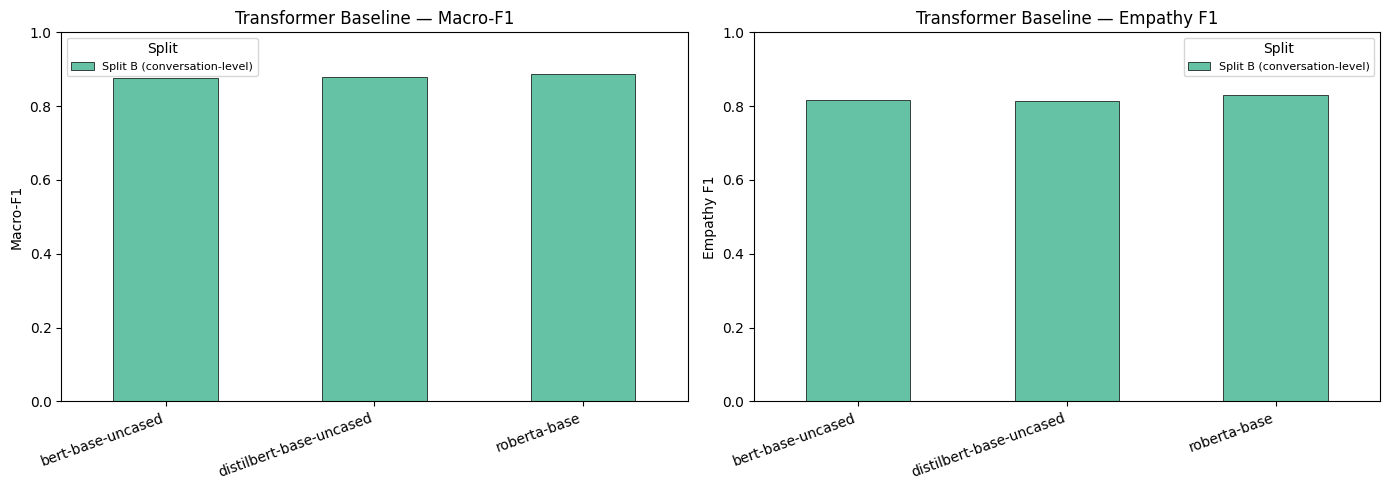

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes,
                              ["test_macro_f1", "test_f1_empathy"],
                              ["Macro-F1", "Empathy F1"]):
    pivot = results_df.pivot(index="model", columns="split", values=metric)
    pivot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="black", linewidth=0.5)
    ax.set_title(f"Transformer Baseline — {title}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
    ax.legend(title="Split", fontsize=8)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "transformer_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
A1 = pd.DataFrame([
    {"Family":"Classical (A1)","Model":"LR + TF-IDF trigrams",
     "Split":"Split B (conversation-level)", "Macro-F1":0.761,"F1(Emp)":0.637,"AUPRC":0.723},
])

best_tr = (
    results_df.loc[results_df.groupby("split")["test_macro_f1"].idxmax()]
    [["model","split","test_macro_f1","test_f1_empathy","test_auprc"]]
    .rename(columns={"model":"Model","split":"Split",
                     "test_macro_f1":"Macro-F1",
                     "test_f1_empathy":"F1(Emp)",
                     "test_auprc":"AUPRC"})
    .assign(Family="Transformer (A2)")
)

comparison = (
    pd.concat([A1, best_tr], ignore_index=True)
    .sort_values(["Split","Family"]).reset_index(drop=True)
)
display(comparison[["Family","Model","Split","Macro-F1","F1(Emp)","AUPRC"]])

,Family,Model,Split,Macro-F1,F1(Emp),AUPRC
0,Classical (A1),LR + TF-IDF trigrams,Split B (conversation-level),0.7610,0.6370,0.7230
1,Transformer (A2),roberta-base,Split B (conversation-level),0.8879,0.8289,0.9204


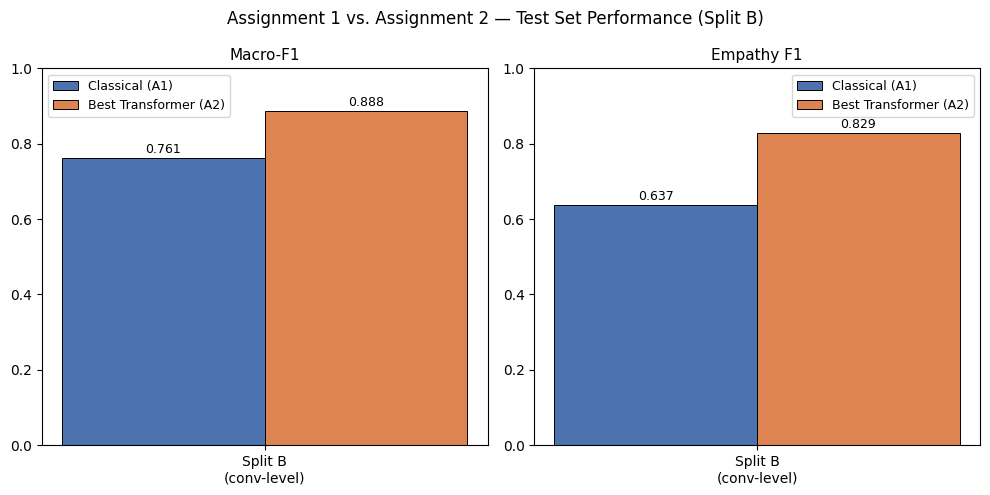

In [15]:
splits_ordered = ["Split B (conversation-level)"]
split_labels   = ["Split B\n(conv-level)"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, col, title in zip(axes, ["Macro-F1","F1(Emp)"], ["Macro-F1","Empathy F1"]):
    a1_vals = [A1[A1["Split"]==s][col].values[0] for s in splits_ordered]
    tr_vals = []
    for s in splits_ordered:
        row = best_tr[best_tr["Split"]==s]
        tr_vals.append(row[col].values[0] if len(row) else np.nan)

    x, w = np.arange(len(splits_ordered)), 0.35
    b1 = ax.bar(x - w/2, a1_vals, w, label="Classical (A1)",        color="#4c72b0", edgecolor="black", linewidth=0.7)
    b2 = ax.bar(x + w/2, tr_vals, w, label="Best Transformer (A2)", color="#dd8452", edgecolor="black", linewidth=0.7)
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                        f"{h:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(split_labels, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

fig.suptitle("Assignment 1 vs. Assignment 2 — Test Set Performance (Split B)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "a1_vs_a2_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusions — Transformer Baseline (Split B)

**All transformers vs. Assignment 1 classical baseline:**

| Model | Macro-F1 | Emp-F1 | Prec(Emp) | Rec(Emp) | AUPRC | Time |
|---|---|---|---|---|---|---|
| RoBERTa-base | **0.888** | **0.829** | 0.899 | 0.769 | **0.920** | 118 min |
| DistilBERT | 0.879 | 0.815 | 0.887 | 0.754 | 0.905 | **59 min** |
| BERT | 0.876 | 0.817 | 0.797 | 0.837 | 0.910 | 118 min |
| **LR + TF-IDF (A1)** | 0.761 | 0.637 | 0.575 | 0.713 | 0.723 | — |

All three transformers substantially outperform the best classical model from Assignment 1: **+0.127 Macro-F1 and +0.192 Emp-F1** for RoBERTa. The improvement is consistent across all three architectures, confirming that contextual representations capture what sparse TF-IDF trigrams cannot — particularly short implicit empathy expressions (*"same here"*, *"I've been there"*) that lack explicit emotional vocabulary and were the dominant false negative error type in A1.

Crucially, transformers improve **both sides** of the A1 error picture: empathy precision rose from 0.575 to 0.899 (fewer advice/support posts misclassified as empathy) while recall remained high. This suggests contextual attention is learning the empathy/advice boundary that bag-of-words features could not encode.

**vs. the Lee & Parde (2024) paper:**

The paper reports RoBERTa empathy F1 = 0.774 on a random post-level split. We obtain 0.829 on the harder conversation-level split (Split B), where no posts from the same thread appear in both train and test. Three methodological differences explain the gap:

1. **Weighted cross-entropy loss** — the paper uses default cross-entropy on a 24%/76% imbalanced dataset. Inverse-frequency weighting directly penalises missed empathy during training.
2. **Threshold tuning on a held-out validation set** — the paper uses a fixed 0.5 threshold. We grid-search 0.10–0.90 on the validation set to maximise Macro-F1 (optimal threshold here: 0.69), then apply it to the test set.
3. **A proper train/val/test split** — the paper uses 80/20 with no validation set, meaning any implicit tuning decisions see the test distribution. Our 64/16/20 split keeps the test set completely held out.

**RoBERTa is the best model** and carries forward to all subsequent experiments. DistilBERT is the efficiency winner — within 0.014 Macro-F1 of RoBERTa at half the training time — making it the practical candidate for compute-heavy bonus experiments (TAPT, LoRA).

---

### References
- Lee & Parde (2024). *AcnEmpathize: A Dataset for Understanding Empathy in Dermatology Conversations.* LREC-COLING.
- Sharma et al. (2020). *A Computational Approach to Understanding Empathy Expressed in Text-Based Mental Health Support.* EMNLP.
- Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* NAACL.
- Liu et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach.* arXiv:1907.11692.
- He et al. (2021). *DeBERTa: Decoding-enhanced BERT with Disentangled Attention.* ICLR.
- Sanh et al. (2019). *DistilBERT, a distilled version of BERT.* NeurIPS EMC2 Workshop.